# **Calidad del servicio energético en Zonas No Interconectadas de Colombia: análisis de 52 municipios con monitoreo de telemetría IPSE 2020-2025**

## **1. CONFIGURACIÓN INICIAL**

### **1.1. Importación de librerias**

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import unicodedata

### **1.2. Definición de rutas**

In [104]:
URL1 = "C:/Users/Lenovo/Desktop/ANALISIS ZNI/DATASETS/DIVIPOLA_-_Códigos_cabeceras_-_Centros_poblados_20260126.csv"
URL2 = "C:/Users/Lenovo/Desktop/ANALISIS ZNI/DATASETS/Estado_de_la_prestación_del_servicio_de_energía_en_Zonas_No_Interconectadas_20260421.csv"
URL3 = "C:/Users/Lenovo/Desktop/ANALISIS ZNI/DATASETS/Anexo_ICEE_2023_dpto_mpio.xlsx"


### **1.3. Funciones**

In [105]:
def eliminar_tildes(texto):
    return unicodedata.normalize('NFD', texto).encode('ascii', 'ignore').decode('utf-8')

## **2. CARGA DE DATOS**

### **2.1. cargue de los tres datasets**

In [106]:
df_localidades = pd.read_csv(URL1).drop(2) #se dropea 2 debido a que tiene doble coma.

df_ZNI = pd.read_csv(URL2 ,decimal=',',thousands= '.')


df_ICEE_municipios = pd.read_excel(URL3, sheet_name='ICEE_MPIO')

### **2.2. exploración datasets**

In [107]:
print('\nInformación dataset: ')
df_ZNI.info()

print('\nforma del dataset:')
df_ZNI.shape

print('\nvalores nulos por columna: ')
print(df_ZNI.isna().sum())

print('\n primeros valores del dataset: ')
df_ZNI.head()



Información dataset: 
<class 'pandas.DataFrame'>
RangeIndex: 6216 entries, 0 to 6215
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID DEPATAMENTO            6216 non-null   int64  
 1   DEPARTAMENTO              6216 non-null   str    
 2   ID MUNICIPIO              6216 non-null   int64  
 3   MUNICIPIO                 6216 non-null   str    
 4   ID LOCALIDAD              6216 non-null   int64  
 5   LOCALIDAD                 6216 non-null   str    
 6   AÑO SERVICIO              6216 non-null   int64  
 7   MES SERVICIO              6216 non-null   int64  
 8   ENERGÍA ACTIVA            6216 non-null   int64  
 9   ENERGÍA REACTIVA          6216 non-null   int64  
 10  POTENCIA MÁXIMA           6132 non-null   float64
 11  DÍA DE DEMANDA MÁXIMA     6131 non-null   str    
 12  FECHA DE DEMANDA MÁXIMA   6132 non-null   str    
 13  PROMEDIO DIARIO EN HORAS  6216 non-null   float64
d

,ID DEPATAMENTO,DEPARTAMENTO,ID MUNICIPIO,MUNICIPIO,ID LOCALIDAD,LOCALIDAD,AÑO SERVICIO,MES SERVICIO,ENERGÍA ACTIVA,ENERGÍA REACTIVA,POTENCIA MÁXIMA,DÍA DE DEMANDA MÁXIMA,FECHA DE DEMANDA MÁXIMA,PROMEDIO DIARIO EN HORAS
0,91,AMAZONAS,91001,LETICIA,91001000,LETICIA (LETICIA - AMAZONAS),2020,1,3930642,1251191,7768.76,lunes,2020 Jan 27 02:15:00 PM,24.00
1,91,AMAZONAS,91540,PUERTO NARIÑO,91540000,PUERTO NARIÑO (PUERTO NARIÑO - AMAZONAS),2020,1,103897,36304,227.04,miércoles,2020 Jan 22 07:15:00 PM,24.00
2,91,AMAZONAS,91798,TARAPACÁ (ANM),91798000,TARAPACÁ (TARAPACÁ (ANM) - AMAZONAS),2020,1,22864,9277,88.96,jueves,2020 Jan 30 07:30:00 PM,10.19
3,5,ANTIOQUIA,5873,VIGÍA DEL FUERTE,5873001,SAN ANTONIO DE PADUA (VIGÍA DEL FUERTE - ANTIO...,2020,1,5617,1381,53.66,jueves,2020 Jan 23 07:45:00 PM,4.13
4,5,ANTIOQUIA,5873,VIGÍA DEL FUERTE,5873002,VEGÁEZ (VIGÍA DEL FUERTE - ANTIOQUIA),2020,1,2217,539,39.07,miércoles,2020 Jan 29 07:45:00 PM,3.17


In [108]:
print('\nInformación dataset: ')
df_localidades.info()

print('\nforma del dataset:')
df_localidades.shape

print('\nvalores nulos por columna: ')
print(df_localidades.isna().sum())

print('\n primeros valores del dataset: ')
df_localidades.head()


Información dataset: 
<class 'pandas.DataFrame'>
Index: 8160 entries, 0 to 8160
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Código Departamento    8160 non-null   int64
 1   Nombre_departamento    8160 non-null   str  
 2   Codigo Municipio       8160 non-null   int64
 3   Nombre Municipio       8160 non-null   str  
 4   Código Centro Poblado  8160 non-null   int64
 5   Nombre Centro Poblado  8160 non-null   str  
 6   Tipo*                  8160 non-null   str  
 7   longitud               8160 non-null   str  
 8   Latitud                8160 non-null   str  
dtypes: int64(3), str(6)
memory usage: 1.0 MB

forma del dataset:

valores nulos por columna: 
Código Departamento      0
Nombre_departamento      0
Codigo Municipio         0
Nombre Municipio         0
Código Centro Poblado    0
Nombre Centro Poblado    0
Tipo*                    0
longitud                 0
Latitud                  0

,Código Departamento,Nombre_departamento,Codigo Municipio,Nombre Municipio,Código Centro Poblado,Nombre Centro Poblado,Tipo*,longitud,Latitud
0,17,CALDAS,17050,ARANZAZU,17050006,SAN RAFAEL,CP,"-75,523505","5,261945"
1,17,CALDAS,17050,ARANZAZU,17050012,LA HONDA,CP,"-75,512562","5,253714"
3,5,ANTIOQUIA,5001,MEDELLÍN,5001001,PALMITAS,CP,"-75,690573","6,343919"
4,5,ANTIOQUIA,5001,MEDELLÍN,5001004,SANTA ELENA,CP,"-75,501293","6,210599"
5,5,ANTIOQUIA,5001,MEDELLÍN,5001009,ALTAVISTA,CP,"-75,643706","6,221429"


In [109]:
print('\nInformación dataset: ')
df_ICEE_municipios.info()

print('\nforma del dataset:')
df_ICEE_municipios.shape

print('\nvalores nulos por columna: ')
print(df_ICEE_municipios.isna().sum())

print('\n primeros valores del dataset: ')
df_ICEE_municipios.head()


Información dataset: 
<class 'pandas.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Cod. DANE         1122 non-null   int64  
 1   Vigencia          1122 non-null   int64  
 2   Departamento      1122 non-null   str    
 3   Municipio         1122 non-null   str    
 4   VCS Urbano        1122 non-null   int64  
 5   VCS Rural         1122 non-null   int64  
 6   VCS Total         1122 non-null   int64  
 7   VT Urbano         1122 non-null   int64  
 8   VT Rural          1122 non-null   int64  
 9   VT                1122 non-null   int64  
 10  ICEE Urbano       1122 non-null   float64
 11  ICEE Rural        1122 non-null   float64
 12  ICEE Total        1122 non-null   float64
 13  VSS Urbano        1122 non-null   int64  
 14  VSS Rural         1122 non-null   int64  
 15  VSS Total         1122 non-null   int64  
 16  Excedentes Total  1122 non-nul

,Cod. DANE,Vigencia,Departamento,Municipio,VCS Urbano,VCS Rural,VCS Total,VT Urbano,VT Rural,VT,ICEE Urbano,ICEE Rural,ICEE Total,VSS Urbano,VSS Rural,VSS Total,Excedentes Total
0,5001,2023,Antioquia,Medellín,1002117,20700,1022817,1002117,20700,1022817,1.000000,1.000000,1.000000,0,0,0,25852
1,5002,2023,Antioquia,Abejorral,3977,4870,8847,4311,5984,10295,0.922524,0.813837,0.859349,334,1114,1448,Sin excedentes
2,5004,2023,Antioquia,Abriaquí,416,671,1087,567,782,1349,0.733686,0.858056,0.805782,151,111,262,Sin excedentes
3,5021,2023,Antioquia,Alejandría,1237,1096,2333,1533,1277,2810,0.806915,0.858262,0.830249,296,181,477,Sin excedentes
4,5030,2023,Antioquia,Amagá,6441,6195,12636,6633,7047,13680,0.971054,0.879097,0.923684,192,852,1044,Sin excedentes


## **3. LIMPIEZA**

### **3.1. ZNI**

In [110]:
df_ZNI['PROMEDIO DIARIO EN HORAS'] = df_ZNI['PROMEDIO DIARIO EN HORAS'].apply(
    lambda x: round(x / 100, 3) if x > 24 else x
)

In [111]:
df_ZNI['ID MUNICIPIO'].nunique()

55

In [112]:
df_ZNI[df_ZNI.groupby('ID MUNICIPIO')['AÑO SERVICIO'].transform('nunique') == 1]

,ID DEPATAMENTO,DEPARTAMENTO,ID MUNICIPIO,MUNICIPIO,ID LOCALIDAD,LOCALIDAD,AÑO SERVICIO,MES SERVICIO,ENERGÍA ACTIVA,ENERGÍA REACTIVA,POTENCIA MÁXIMA,DÍA DE DEMANDA MÁXIMA,FECHA DE DEMANDA MÁXIMA,PROMEDIO DIARIO EN HORAS
43,27,CHOCÓ,27745,SIPÍ,27745000,SIPÍ (SIPÍ - CHOCO),2020,1,10872,3028,74.80,miércoles,2020 Jan 29 08:15:00 PM,5.4200
127,27,CHOCÓ,27745,SIPÍ,27745000,SIPÍ (SIPÍ - CHOCO),2020,2,11522,3225,79.20,martes,2020 Feb 18 08:00:00 PM,6.1500
204,27,CHOCÓ,27745,SIPÍ,27745000,SIPÍ (SIPÍ - CHOCO),2020,3,10875,3018,79.20,jueves,2020 Mar 12 07:15:00 PM,5.3600
279,27,CHOCÓ,27745,SIPÍ,27745000,SIPÍ (SIPÍ - CHOCO),2020,4,11009,3069,74.80,jueves,2020 Apr 30 07:15:00 PM,5.5100
353,27,CHOCÓ,27745,SIPÍ,27745000,SIPÍ (SIPÍ - CHOCO),2020,5,10450,2798,79.20,lunes,2020 May 25 07:00:00 PM,5.2100
418,27,CHOCÓ,27745,SIPÍ,27745000,SIPÍ (SIPÍ - CHOCO),2020,6,10264,3066,79.20,martes,2020 Jun 02 07:00:00 PM,21.3400
486,27,CHOCÓ,27745,SIPÍ,27745000,SIPÍ (SIPÍ - CHOCO),2020,7,10668,3496,74.80,viernes,2020 Jul 31 07:00:00 PM,5.3400
564,27,CHOCÓ,27745,SIPÍ,27745000,SIPÍ (SIPÍ - CHOCO),2020,8,7284,2784,79.20,jueves,2020 Aug 13 07:30:00 PM,3.5300
644,27,CHOCÓ,27745,SIPÍ,27745000,SIPÍ (SIPÍ - CHOCO),2020,9,11104,4136,74.80,martes,2020 Sep 29 07:30:00 PM,6.1100
724,27,CHOCÓ,27745,SIPÍ,27745000,SIPÍ (SIPÍ - CHOCO),2020,10,10987,3835,74.80,sábado,2020 Oct 31 06:45:00 PM,5.5200


In [113]:
prueba =df_ZNI[df_ZNI['PROMEDIO DIARIO EN HORAS'] > 24].sort_values('PROMEDIO DIARIO EN HORAS', ascending=False)
prueba

,ID DEPATAMENTO,DEPARTAMENTO,ID MUNICIPIO,MUNICIPIO,ID LOCALIDAD,LOCALIDAD,AÑO SERVICIO,MES SERVICIO,ENERGÍA ACTIVA,ENERGÍA REACTIVA,POTENCIA MÁXIMA,DÍA DE DEMANDA MÁXIMA,FECHA DE DEMANDA MÁXIMA,PROMEDIO DIARIO EN HORAS


In [114]:
# Se eliminan las columnas de fecha y día de demanda máxima, ya que no aportan información relevante para el análisis.
df_ZNI.drop(columns= ['DÍA DE DEMANDA MÁXIMA', 'FECHA DE DEMANDA MÁXIMA', 'POTENCIA MÁXIMA'], inplace = True)

df_ZNI = df_ZNI[df_ZNI['AÑO SERVICIO'] != 2026].copy()

#se llennan los valores faltantes con 0, ya que significa que la generación de ener en esa ZNI es 0.
df_ZNI.fillna(0, inplace = True)

#Se corrige nombre de la columna departamentos en dataframe de ZNI
df_ZNI.rename(columns = {'ID DEPATAMENTO' : 'ID DEPARTAMENTO'}, inplace = True)

#Se dropean las filas que tengan un valor mayor a 24h en promedio diario de horas de servicio.
df_ZNI = df_ZNI[df_ZNI['PROMEDIO DIARIO EN HORAS'] <= 24].copy()
df_ZNI = df_ZNI[df_ZNI.groupby('ID MUNICIPIO')['AÑO SERVICIO'].transform('nunique') >= 2].copy()



# 1. Limpieza de texto
df_ZNI['LOCALIDAD'] = (
    df_ZNI['LOCALIDAD']
    .str.split(r'\(')
    .str[0]
    .str.strip()
)

# 2. Estandarización: Agrupar por ID LOCALIDAD
df_ZNI['LOCALIDAD'] = (
    df_ZNI
    .groupby('ID LOCALIDAD')['LOCALIDAD']
    .transform('first')
)

# 3. Preparar diccionarios
mapeo_divipola = dict(df_localidades[['Código Centro Poblado', 'Nombre Centro Poblado']].values)

mapeo_ZNI = (
    df_ZNI
    .drop_duplicates(subset=['ID LOCALIDAD'])
    .set_index('ID LOCALIDAD')['LOCALIDAD']
    .to_dict()
)

# Después de los pasos 1-3, aplica directo:
df_ZNI['LOCALIDAD'] = (
    df_ZNI['ID LOCALIDAD']
    .map(mapeo_divipola)
    .fillna(df_ZNI['ID LOCALIDAD'].map(mapeo_ZNI))
)

In [115]:
df_ZNI.groupby('ID LOCALIDAD')['LOCALIDAD'].transform('first')


0                    LETICIA
1              PUERTO NARIÑO
2                   TARAPACÁ
3       SAN ANTONIO DE PADUA
4                     VEGAEZ
                ...         
6206                    MITÚ
6208                 TARAIRA
6210                CUMARIBO
6212               CASUARITO
6214          PUERTO CARREÑO
Name: LOCALIDAD, Length: 6076, dtype: str

### **3.2. ICEE MUNICIPAL**

In [116]:
df_ICEE_municipios.columns = df_ICEE_municipios.columns.str.upper()

df_ICEE_municipios = (
    df_ICEE_municipios
    .rename(columns = {'COD. DANE' : 'ID MUNICIPIO'})
    .drop(columns = 'VIGENCIA')) #Se dropea columna vigencia ya que todos los datos son del 2023


### **3.3. DIVIPOLA**

In [117]:
df_localidades[['longitud', 'Latitud']] = (
    df_localidades[['longitud', 'Latitud']]
    .replace(",",
             ".",
             regex=True
             )
    .astype(float))

df_localidades.columns = (
    df_localidades.columns
    .map(eliminar_tildes)
    .str.upper()
    .str.strip()
    )

df_localidades = (
    df_localidades
    .rename(
        columns = {'TIPO*' : 'TIPO'
                   ,'CODIGO DEPARTAMENTO' : 'ID DEPARTAMENTO'
                   ,'NOMBRE_DEPARTAMENTO' : 'DEPARTAMENTO',
                   'CODIGO MUNICIPIO' : 'ID MUNICIPIO',
                   'NOMBRE MUNICIPIO' : 'MUNICIPIO',
                   'CODIGO CENTRO POBLADO' : 'ID LOCALIDAD',
                   'NOMBRE CENTRO POBLADO' : 'LOCALIDAD'})
                   )

## **4. INTEGRACIÓN**

### **4.1. Combinación ZNI-DIVIPOLA**

In [118]:
df_municipios = (
    df_localidades
    .groupby(['ID DEPARTAMENTO', 'ID MUNICIPIO'], as_index=False)
    .first()[['ID DEPARTAMENTO', 'ID MUNICIPIO', 'DEPARTAMENTO', 'MUNICIPIO', 'LONGITUD', 'LATITUD']])

df_ZNI_limpio = (
    pd.merge(
        df_ZNI, df_municipios,
        how='left',
        on=['ID DEPARTAMENTO', 'ID MUNICIPIO'],
        validate='many_to_one',
        suffixes=('_dropear', '')
    )
    .drop(columns=['DEPARTAMENTO_dropear', 'MUNICIPIO_dropear'])
    .dropna(subset=['DEPARTAMENTO', 'MUNICIPIO'])
)

cols_iniciales = ['ID DEPARTAMENTO', 'DEPARTAMENTO', 'ID MUNICIPIO', 'MUNICIPIO']
cols_restantes = df_ZNI_limpio.columns.drop(cols_iniciales).tolist()
ordenar_columnas = cols_iniciales + cols_restantes
df_ZNI_limpio = df_ZNI_limpio[ordenar_columnas]

df_ZNI_limpio


,ID DEPARTAMENTO,DEPARTAMENTO,ID MUNICIPIO,MUNICIPIO,ID LOCALIDAD,LOCALIDAD,AÑO SERVICIO,MES SERVICIO,ENERGÍA ACTIVA,ENERGÍA REACTIVA,PROMEDIO DIARIO EN HORAS,LONGITUD,LATITUD
0,91,AMAZONAS,91001,LETICIA,91001000,LETICIA,2020,1,3930642,1251191,24.00,-69.941721,-4.198950
1,91,AMAZONAS,91540,PUERTO NARIÑO,91540000,PUERTO NARIÑO,2020,1,103897,36304,24.00,-70.364937,-3.779934
2,91,AMAZONAS,91798,TARAPACÁ,91798000,TARAPACÁ,2020,1,22864,9277,10.19,-69.741745,-2.890126
3,5,ANTIOQUIA,5873,VIGÍA DEL FUERTE,5873001,SAN ANTONIO DE PADUA,2020,1,5617,1381,4.13,-76.896004,6.588164
4,5,ANTIOQUIA,5873,VIGÍA DEL FUERTE,5873002,VEGAEZ,2020,1,2217,539,3.17,-76.896004,6.588164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6071,97,VAUPÉS,97001,MITÚ,97001000,MITÚ,2025,12,1618735,350404,24.00,-70.232641,1.253151
6072,97,VAUPÉS,97666,TARAIRA,97666000,TARAIRA,2025,12,41722,11023,11.56,-69.635497,-0.564984
6073,99,VICHADA,99773,CUMARIBO,99773000,CUMARIBO,2025,12,425095,140699,23.83,-69.795533,4.446352
6074,99,VICHADA,99001,PUERTO CARREÑO,99001002,CASUARITO,2025,12,17392,8779,9.60,-67.487095,6.186636


In [119]:
df_ZNI_limpio.info()

<class 'pandas.DataFrame'>
Index: 6075 entries, 0 to 6075
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID DEPARTAMENTO           6075 non-null   int64  
 1   DEPARTAMENTO              6075 non-null   str    
 2   ID MUNICIPIO              6075 non-null   int64  
 3   MUNICIPIO                 6075 non-null   str    
 4   ID LOCALIDAD              6075 non-null   int64  
 5   LOCALIDAD                 6075 non-null   str    
 6   AÑO SERVICIO              6075 non-null   int64  
 7   MES SERVICIO              6075 non-null   int64  
 8   ENERGÍA ACTIVA            6075 non-null   int64  
 9   ENERGÍA REACTIVA          6075 non-null   int64  
 10  PROMEDIO DIARIO EN HORAS  6075 non-null   float64
 11  LONGITUD                  6075 non-null   float64
 12  LATITUD                   6075 non-null   float64
dtypes: float64(3), int64(7), str(3)
memory usage: 851.5 KB


### **4.2. Filtrar ICEEE**

In [120]:
ids_ZNI = df_ZNI_limpio['ID MUNICIPIO'].unique()   


df_ref = df_municipios.drop(columns = ['LATITUD', 'LONGITUD']) 



df_ICEE_final = (
    df_ICEE_municipios[df_ICEE_municipios['ID MUNICIPIO'].isin(ids_ZNI)]
    .copy()
    .merge(df_ref,how='left',on='ID MUNICIPIO',validate='many_to_one',suffixes=('_dropear', ''))
    .loc[:, lambda x: ~x.columns.str.endswith('_dropear')]
)

cols_iniciales = ['ID DEPARTAMENTO', 'DEPARTAMENTO', 'ID MUNICIPIO', 'MUNICIPIO']
cols_restantes = df_ICEE_final.columns.drop(cols_iniciales).tolist()
ordenar_columnas = cols_iniciales + cols_restantes
df_ICEE_final = df_ICEE_final[ordenar_columnas]

df_ICEE_final


,ID DEPARTAMENTO,DEPARTAMENTO,ID MUNICIPIO,MUNICIPIO,VCS URBANO,VCS RURAL,VCS TOTAL,VT URBANO,VT RURAL,VT,ICEE URBANO,ICEE RURAL,ICEE TOTAL,VSS URBANO,VSS RURAL,VSS TOTAL,EXCEDENTES TOTAL
0,5,ANTIOQUIA,5873,VIGÍA DEL FUERTE,682,1880,2562,1450,1880,3330,0.470345,1.000000,0.769369,768,0,768,Sin excedentes
1,13,BOLÍVAR,13001,CARTAGENA DE INDIAS,314150,20635,334785,314150,40598,354748,1.000000,0.508276,0.943726,0,19963,19963,Sin excedentes
2,18,CAQUETÁ,18150,CARTAGENA DEL CHAIRÁ,1,1150,1151,6817,5196,12013,0.000147,0.221324,0.095813,6816,4046,10862,Sin excedentes
3,18,CAQUETÁ,18753,SAN VICENTE DEL CAGUÁN,9556,7538,17094,9996,7621,17617,0.955982,0.989109,0.970313,440,83,523,Sin excedentes
4,19,CAUCA,19318,GUAPI,4525,3584,8109,4525,4271,8796,1.000000,0.839148,0.921896,0,687,687,Sin excedentes
5,19,CAUCA,19418,LÓPEZ DE MICAY,805,5748,6553,805,5748,6553,1.000000,1.000000,1.000000,0,0,0,2429
6,19,CAUCA,19809,TIMBIQUÍ,1907,7541,9448,1907,7652,9559,1.000000,0.985494,0.988388,0,111,111,Sin excedentes
7,27,CHOCÓ,27001,QUIBDÓ,42720,7384,50104,42720,7384,50104,1.000000,1.000000,1.000000,0,0,0,9288
8,27,CHOCÓ,27006,ACANDÍ,2432,3959,6391,2432,3959,6391,1.000000,1.000000,1.000000,0,0,0,2500
9,27,CHOCÓ,27025,ALTO BAUDÓ,782,4399,5181,1113,6440,7553,0.702606,0.683075,0.685953,331,2041,2372,Sin excedentes


In [121]:
df_anual = (
    df_ZNI_limpio
    .groupby(['ID MUNICIPIO', 'MUNICIPIO', 'DEPARTAMENTO', 'AÑO SERVICIO'])
    .agg({'PROMEDIO DIARIO EN HORAS': 'mean','ENERGÍA ACTIVA': 'sum','ENERGÍA REACTIVA': 'sum'})
    .reset_index()
    )

df_anual['POTENCIA APARENTE'] = round(np.sqrt(df_anual['ENERGÍA ACTIVA']**2 + df_anual['ENERGÍA REACTIVA']**2), 3)

df_anual['FACTOR DE POTENCIA'] = round(df_anual['ENERGÍA ACTIVA'] / df_anual['POTENCIA APARENTE'], 3)

df_anual

,ID MUNICIPIO,MUNICIPIO,DEPARTAMENTO,AÑO SERVICIO,PROMEDIO DIARIO EN HORAS,ENERGÍA ACTIVA,ENERGÍA REACTIVA,POTENCIA APARENTE,FACTOR DE POTENCIA
0,5873,VIGÍA DEL FUERTE,ANTIOQUIA,2020,7.531212,1081104,353392,1137396.925,0.951
1,5873,VIGÍA DEL FUERTE,ANTIOQUIA,2021,7.737692,987743,399456,1065458.272,0.927
2,5873,VIGÍA DEL FUERTE,ANTIOQUIA,2022,4.959000,35895,4572,36185.000,0.992
3,5873,VIGÍA DEL FUERTE,ANTIOQUIA,2023,9.270000,70272,18015,72544.429,0.969
4,5873,VIGÍA DEL FUERTE,ANTIOQUIA,2024,10.333077,80119,35454,87613.014,0.914
...,...,...,...,...,...,...,...,...,...
276,99773,CUMARIBO,VICHADA,2020,22.240000,3247928,1423589,3546215.156,0.916
277,99773,CUMARIBO,VICHADA,2021,22.957273,3361989,1435331,3655563.584,0.920
278,99773,CUMARIBO,VICHADA,2022,23.387273,3550514,1478761,3846151.812,0.923
279,99773,CUMARIBO,VICHADA,2023,23.578571,2281310,915515,2458158.463,0.928


## **5. ANÁLISIS EXPLORATORIO**

In [122]:
df_promedio_horas_servicio = pd.DataFrame(df_ZNI_limpio.groupby(df_ZNI_limpio['AÑO SERVICIO'])['PROMEDIO DIARIO EN HORAS'].mean())
df_promedio_horas_servicio

,PROMEDIO DIARIO EN HORAS
AÑO SERVICIO,
2020,11.390470
2021,12.137646
2022,12.799361
2023,11.658110
2024,11.630728
2025,10.641500


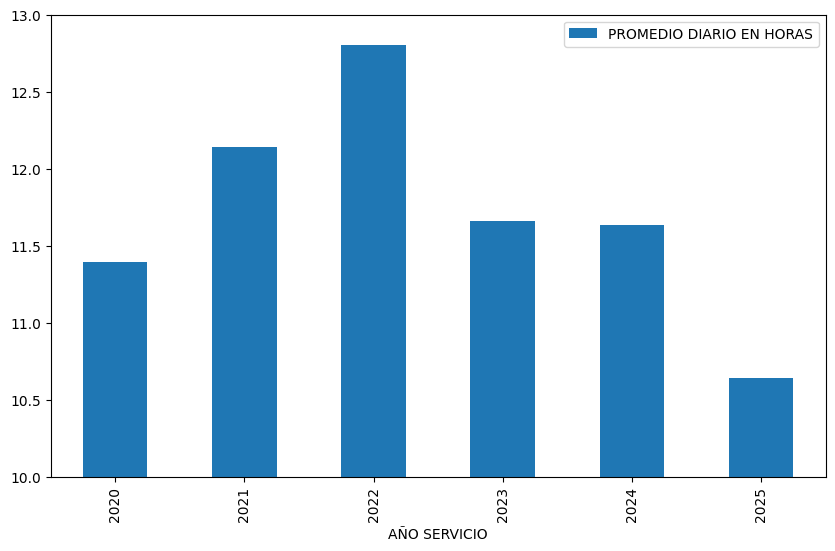

In [123]:
df_promedio_horas_servicio.plot(kind = 'bar', figsize = (10, 6), ylim=(10, 13));

In [124]:
list(df_ZNI_limpio['MUNICIPIO'].unique())

['LETICIA',
 'PUERTO NARIÑO',
 'TARAPACÁ',
 'VIGÍA DEL FUERTE',
 'PROVIDENCIA',
 'SAN ANDRÉS',
 'CARTAGENA DE INDIAS',
 'CARTAGENA DEL CHAIRÁ',
 'SAN VICENTE DEL CAGUÁN',
 'TRINIDAD',
 'LÓPEZ DE MICAY',
 'TIMBIQUÍ',
 'ACANDÍ',
 'ALTO BAUDÓ',
 'BAHÍA SOLANO',
 'BAJO BAUDÓ',
 'BOJAYÁ',
 'EL LITORAL DEL SAN JUAN',
 'MEDIO ATRATO',
 'NUQUÍ',
 'QUIBDÓ',
 'UNGUÍA',
 'BARRANCOMINAS',
 'INÍRIDA',
 'MIRAFLORES',
 'URIBIA',
 'CIÉNAGA',
 'MAPIRIPÁN',
 'EL CHARCO',
 'LA TOLA',
 'OLAYA HERRERA',
 'SAN ANDRÉS DE TUMACO',
 'SANTA BÁRBARA',
 'PUERTO LEGUÍZAMO',
 'BUENAVENTURA',
 'CARURÚ',
 'MITÚ',
 'TARAIRA',
 'CUMARIBO',
 'LA PRIMAVERA',
 'PUERTO CARREÑO',
 'SANTA ROSALÍA',
 'GUAPI',
 'JURADÓ',
 'FRANCISCO PIZARRO',
 'MOSQUERA',
 'ISTMINA',
 'MEDIO SAN JUAN',
 'RIOSUCIO',
 'MAGÜÍ',
 'ROBERTO PAYÁN',
 'NÓVITA']

In [125]:
df_ZNI_limpio['MUNICIPIO'].value_counts()

MUNICIPIO
TIMBIQUÍ                   393
BUENAVENTURA               365
BAJO BAUDÓ                 307
LA TOLA                    280
LÓPEZ DE MICAY             266
NUQUÍ                      266
EL CHARCO                  238
BOJAYÁ                     235
SAN ANDRÉS DE TUMACO       210
UNGUÍA                     206
BAHÍA SOLANO               186
CARTAGENA DE INDIAS        172
SAN VICENTE DEL CAGUÁN     170
VIGÍA DEL FUERTE           151
ACANDÍ                     140
GUAPI                      121
ALTO BAUDÓ                 120
SANTA BÁRBARA              119
JURADÓ                     118
PUERTO CARREÑO             114
PUERTO LEGUÍZAMO           113
EL LITORAL DEL SAN JUAN    110
MEDIO ATRATO               110
INÍRIDA                    109
CARTAGENA DEL CHAIRÁ       106
BARRANCOMINAS               76
OLAYA HERRERA               74
CIÉNAGA                     71
MITÚ                        71
LETICIA                     70
URIBIA                      69
MAPIRIPÁN                   6

In [126]:
df_ZNI_limpio['DEPARTAMENTO'].unique()

<ArrowStringArray>
[                                                'AMAZONAS',
                                                'ANTIOQUIA',
 'ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANTA CATALINA',
                                                  'BOLÍVAR',
                                                  'CAQUETÁ',
                                                 'CASANARE',
                                                    'CAUCA',
                                                    'CHOCÓ',
                                                  'GUAINÍA',
                                                 'GUAVIARE',
                                               'LA GUAJIRA',
                                                'MAGDALENA',
                                                     'META',
                                                   'NARIÑO',
                                                 'PUTUMAYO',
                                          'VALLE DEL CAUCA',
     

In [127]:
df_ZNI_limpio.isna().sum()

ID DEPARTAMENTO             0
DEPARTAMENTO                0
ID MUNICIPIO                0
MUNICIPIO                   0
ID LOCALIDAD                0
LOCALIDAD                   0
AÑO SERVICIO                0
MES SERVICIO                0
ENERGÍA ACTIVA              0
ENERGÍA REACTIVA            0
PROMEDIO DIARIO EN HORAS    0
LONGITUD                    0
LATITUD                     0
dtype: int64

In [128]:
import pandas as pd
import numpy as np
from scipy import stats

def calcular_tendencia(grupo):
    x = grupo['AÑO SERVICIO'].values
    y = grupo['PROMEDIO DIARIO EN HORAS'].values
    
    slope, intercept, r, p, se = stats.linregress(x, y)
    
    # Métricas adicionales
    cv = np.std(y) / np.mean(y)  # Coeficiente de variación
    rango = np.max(y) - np.min(y)
    
    # Clasificación de 2 dimensiones
    if p <= 0.05:
        direccion = 'mejora' if slope > 0 else 'regresion'
    else:
        direccion = 'sin_tendencia_lineal'
    
    # Estabilidad
    if cv < 0.1:
        estabilidad = 'estable'
    elif cv < 0.3:
        estabilidad = 'variable'
    else:
        estabilidad = 'muy_variable'
    
    return pd.Series({
        'pendiente': slope,
        'p_value': p,
        'r2': r**2,
        'cv': cv,
        'rango': rango,
        'direccion': direccion,
        'estabilidad': estabilidad,
        'clasificacion_final': f"{direccion}_{estabilidad}"
    })

# Aplicar agrupación
df_tendencias = (
    df_anual
    .groupby(['ID MUNICIPIO', 'MUNICIPIO', 'DEPARTAMENTO'], group_keys=False)
    .apply(calcular_tendencia)
    .reset_index()
)

# Formato correcto para R² en porcentaje (ej: 85.3 en lugar de 85.345)
df_tendencias['r2'] = (df_tendencias['r2'] * 100).round(1)

In [132]:
df_tendencias

,ID MUNICIPIO,MUNICIPIO,DEPARTAMENTO,pendiente,p_value,r2,cv,rango,direccion,estabilidad,clasificacion_final
0,5873,VIGÍA DEL FUERTE,ANTIOQUIA,0.000747,0.999031,0.0,0.263344,5.374077,sin_tendencia_lineal,variable,sin_tendencia_lineal_variable
1,13001,CARTAGENA DE INDIAS,BOLÍVAR,-0.099909,0.836930,1.2,0.149279,4.330758,sin_tendencia_lineal,variable,sin_tendencia_lineal_variable
2,18150,CARTAGENA DEL CHAIRÁ,CAQUETÁ,-0.725774,0.019181,78.3,0.231181,3.967292,regresion,variable,regresion_variable
3,18753,SAN VICENTE DEL CAGUÁN,CAQUETÁ,-0.746624,0.120085,49.3,0.198013,5.600056,sin_tendencia_lineal,variable,sin_tendencia_lineal_variable
4,19318,GUAPI,CAUCA,0.191206,0.538639,10.1,0.128214,3.248167,sin_tendencia_lineal,variable,sin_tendencia_lineal_variable
5,19418,LÓPEZ DE MICAY,CAUCA,-0.331078,0.071486,59.7,0.129168,2.115739,sin_tendencia_lineal,variable,sin_tendencia_lineal_variable
6,19809,TIMBIQUÍ,CAUCA,0.089304,0.369567,20.3,0.052003,1.035392,sin_tendencia_lineal,estable,sin_tendencia_lineal_estable
7,27001,QUIBDÓ,CHOCÓ,-0.410556,0.464514,14.0,0.376875,5.164167,sin_tendencia_lineal,muy_variable,sin_tendencia_lineal_muy_variable
8,27006,ACANDÍ,CHOCÓ,-0.711306,0.007987,85.8,0.080994,3.860804,regresion,estable,regresion_estable
9,27025,ALTO BAUDÓ,CHOCÓ,-1.741206,0.253641,30.7,0.281868,15.013406,sin_tendencia_lineal,variable,sin_tendencia_lineal_variable


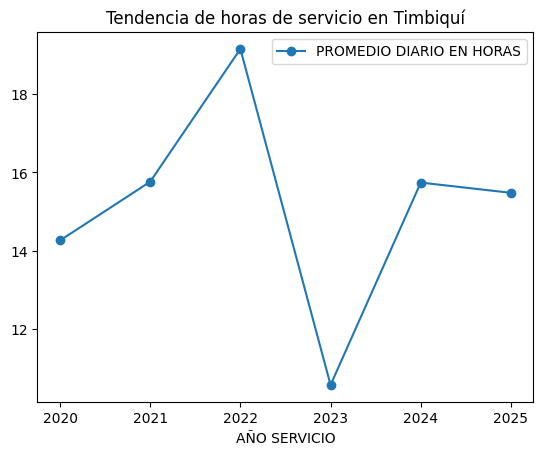

In [129]:
df_anual[df_anual['MUNICIPIO'] == 'NUQUÍ'].plot(x='AÑO SERVICIO', y='PROMEDIO DIARIO EN HORAS', kind='line', marker='o', title='Tendencia de horas de servicio en Timbiquí');

Máximo: nan
Mínimo: nan


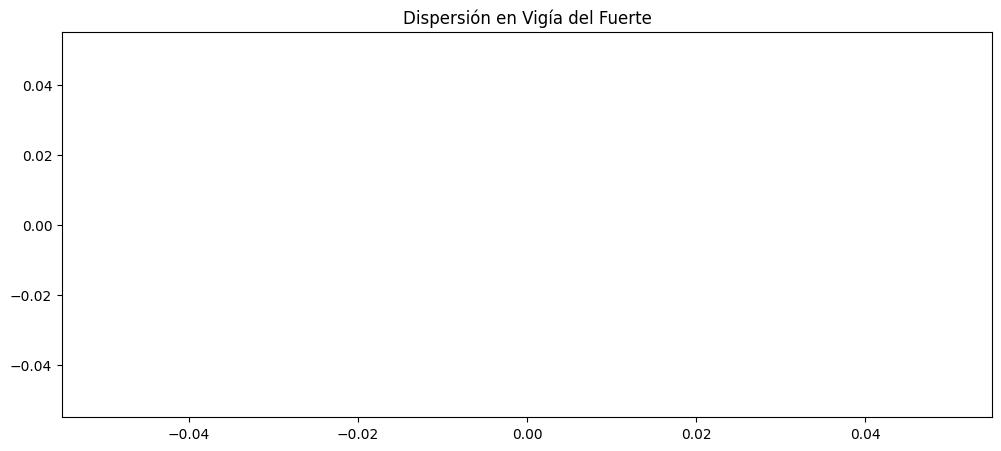

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar solo Vigía del Fuerte para ver el problema
df_vigia = df_ZNI_limpio[df_ZNI_limpio['ID MUNICIPIO'] == '05873'] # O el ID correcto si es numérico 5873

# Verifica los valores máximos y mínimos reales
print("Máximo:", df_vigia['PROMEDIO DIARIO EN HORAS'].max())
print("Mínimo:", df_vigia['PROMEDIO DIARIO EN HORAS'].min())

# Gráfica para ver el desorden
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df_vigia, x='AÑO SERVICIO', y='PROMEDIO DIARIO EN HORAS')
plt.title('Dispersión en Vigía del Fuerte')
plt.show()

In [131]:
df_tendencias.sort_values( by = ['clasificacion', 'r2'], ascending=[True, False])

KeyError: 'clasificacion'

## **6. EXPORTACIÓN**

clasificacion
estancamiento    41
mejora            6
regresion         5
Name: count, dtype: int64


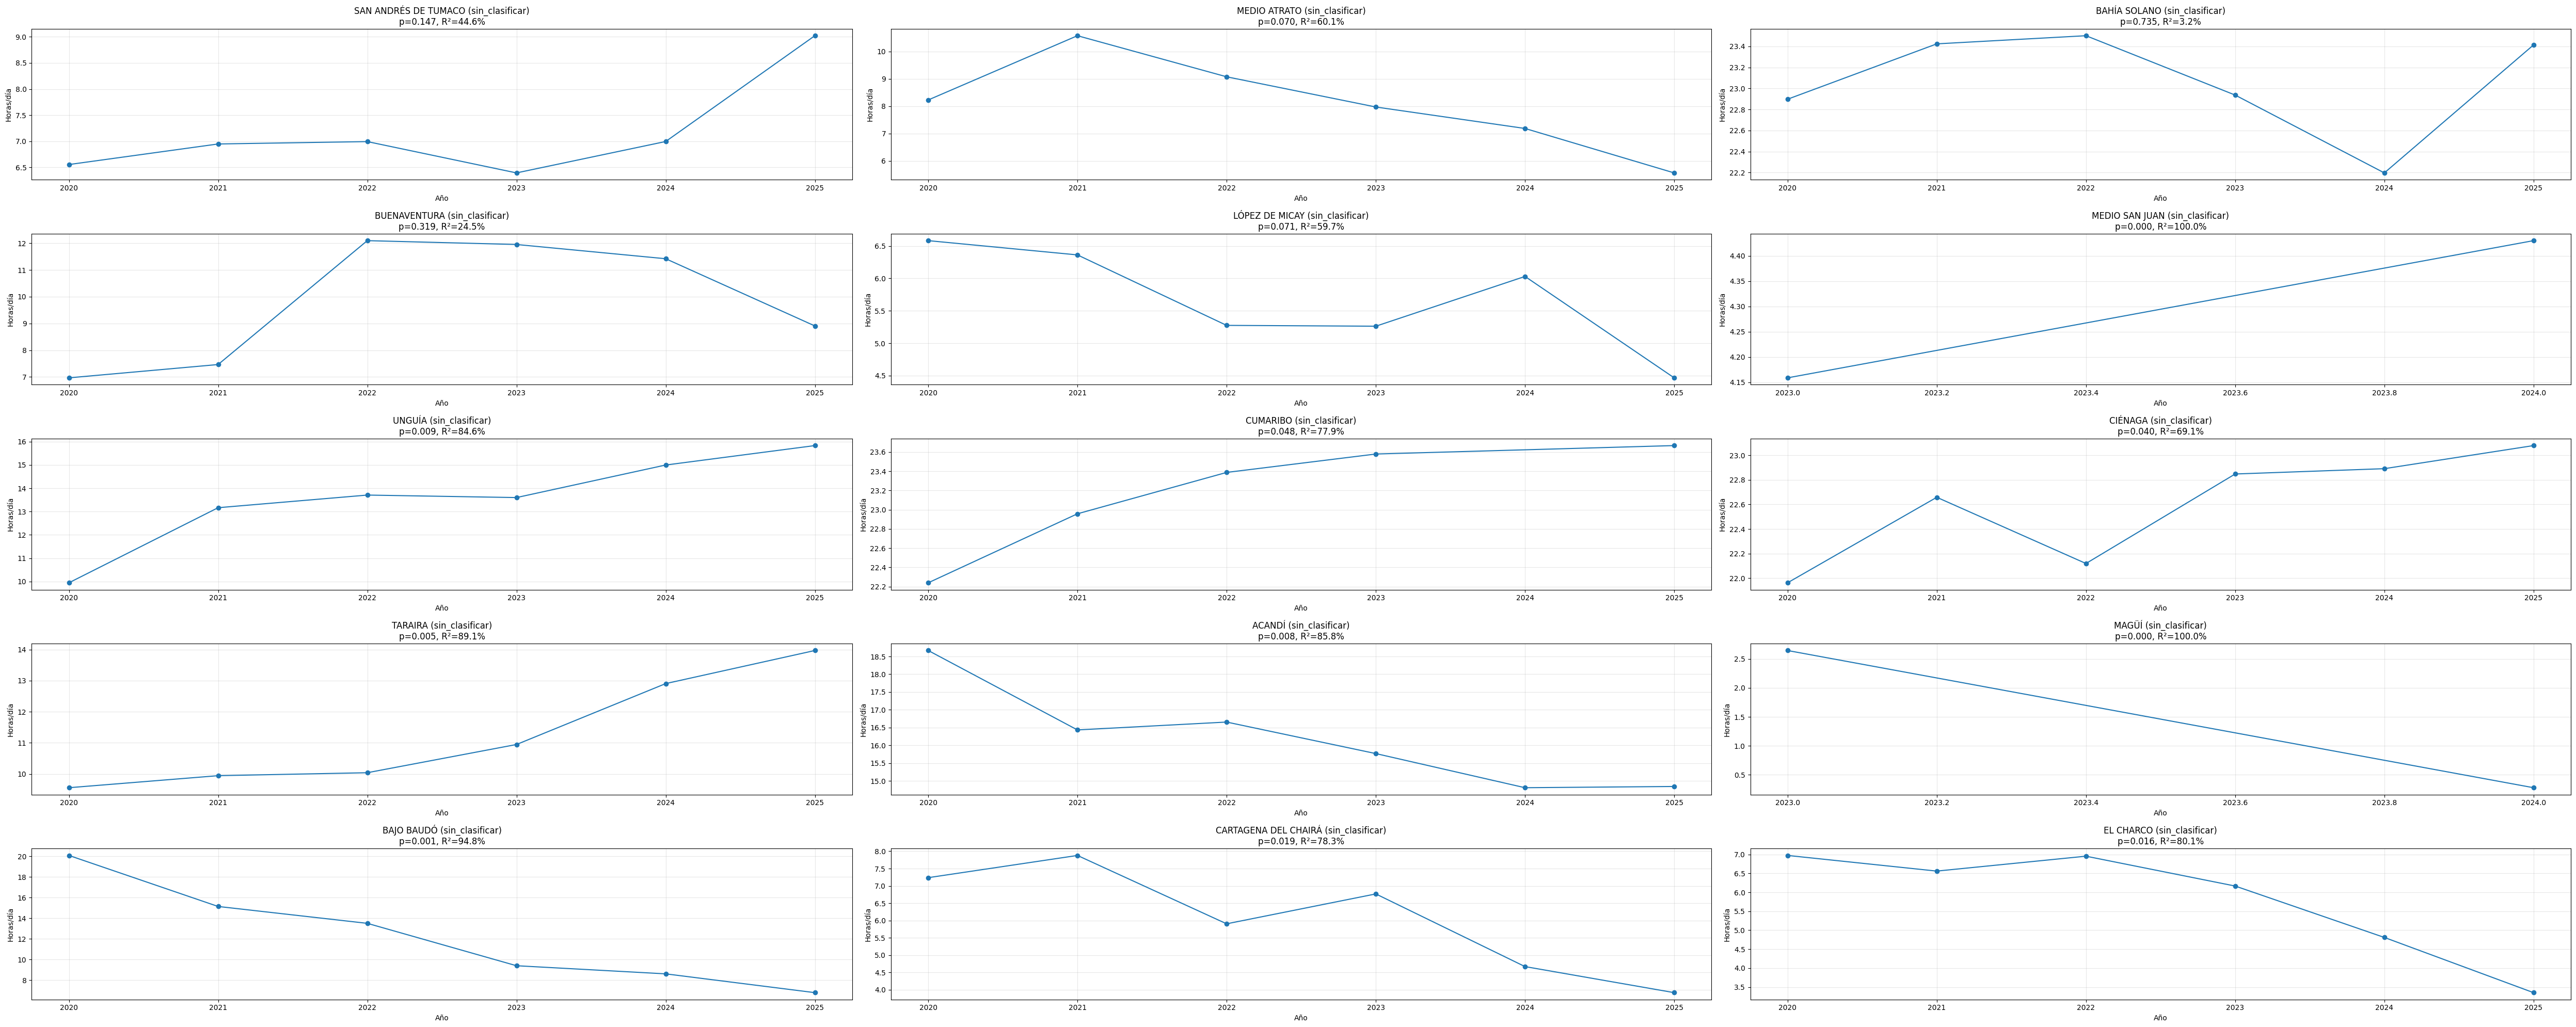

In [ ]:
# Distribución de clasificaciones
print(df_tendencias['clasificacion'].value_counts(dropna=False))

# Panel de ejemplos representativos
ejemplos = (
    df_tendencias
    .groupby('clasificacion', group_keys=False)
    .apply(lambda g: g.sample(n=min(5, len(g)), random_state=42))
    .reset_index(drop=True)
)
plt.figure(figsize=(50, 20))
for i, row in ejemplos.iterrows():
    df_mun = df_anual[df_anual['ID MUNICIPIO'] == row['ID MUNICIPIO']]
    plt.subplot(int(np.ceil(len(ejemplos) / 3)), 3, i + 1)
    plt.plot(df_mun['AÑO SERVICIO'], df_mun['PROMEDIO DIARIO EN HORAS'], 'o-', label=row['MUNICIPIO'])
    clasif = row.get('clasificacion', 'sin_clasificar')
    p_val = row.get('p_value', np.nan)
    r2_val = row.get('r2', np.nan)
    plt.title(f"{row['MUNICIPIO']} ({clasif})\np={p_val:.3f}, R²={r2_val:.1f}%")
    plt.xlabel('Año'); plt.ylabel('Horas/día')
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
ejemplos 

,ID MUNICIPIO,MUNICIPIO,DEPARTAMENTO,pendiente,p_value,r2
0,52835,SAN ANDRÉS DE TUMACO,NARIÑO,0.339042,0.147094,44.6
1,27425,MEDIO ATRATO,CHOCÓ,-0.703251,0.070100,60.1
2,27075,BAHÍA SOLANO,CHOCÓ,-0.047619,0.734501,3.2
3,76109,BUENAVENTURA,VALLE DEL CAUCA,0.611955,0.318562,24.5
4,19418,LÓPEZ DE MICAY,CAUCA,-0.331078,0.071486,59.7
5,27450,MEDIO SAN JUAN,CHOCÓ,0.271429,0.000000,100.0
6,27800,UNGUÍA,CHOCÓ,0.994689,0.009386,84.6
7,99773,CUMARIBO,VICHADA,0.268549,0.047506,77.9
8,47189,CIÉNAGA,MAGDALENA,0.200040,0.040350,69.1
9,97666,TARAIRA,VAUPÉS,0.909217,0.004598,89.1
